# Visualize Pre-Computed Global Front Results

This notebook loads pre-computed front properties from `process_global_fronts.py` and creates visualizations.

**Prerequisites:**
- Run `process_global_fronts.py` first to generate results
- Have the labeled array, properties files, and original data available

In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import xarray as xr
import pandas as pd
from pathlib import Path
import json
from scipy.stats import gaussian_kde

plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['font.size'] = 10
%matplotlib inline

print("Imports successful!")

Imports successful!


## 1. Load Pre-Computed Results

**Note:** If you processed with `--downsample`, this cell will automatically apply the same downsampling to coordinates and divb2 to match the labeled array.

In [ ]:
# === FILE PATHS - UPDATE THESE ===
results_dir = '/mnt/tank/Oceanography/data/OGCM/LLC/Fronts/lohoff/group_fronts/'  # Directory with processed results
coords_file = '/mnt/tank/Oceanography/data/OGCM/LLC/Fronts/lohoff/group_fronts/LLC_coords_lat_lon.nc'  # Same coords used in processing
divb2_file = '/mnt/tank/Oceanography/data/OGCM/LLC/Fronts/derived/LLC4320_2012-11-09T12_00_00_Divb2.nc'  # For background maps

# === EXTRACT TIMESTEP FROM DIVB2 FILENAME ===
print("Extracting timestep from divb2_file...")
import re
from pathlib import Path

# Pattern to match: YYYY-MM-DDTHH_MM_SS
pattern = r'(\d{4}-\d{2}-\d{2}T\d{2}_\d{2}_\d{2})'
match = re.search(pattern, divb2_file)

if match:
    time_str_raw = match.group(1)
    time_str = time_str_raw.replace('_', ':')  # Human-readable: 2012-11-09T12:00:00
    time_str_safe = time_str.replace(':', '_').replace('-', '')  # Filename-safe: 20121109T12_00_00
    print(f"  Extracted timestep: {time_str}")
    print(f"  Filename format: {time_str_safe}")
else:
    raise ValueError(f"Could not extract timestep from divb2_file: {divb2_file}")

# === CONSTRUCT FILENAMES WITH TIMESTEP ===
metadata_file = Path(results_dir) / f'metadata_{time_str_safe}.json'
labeled_file = Path(results_dir) / f'labeled_fronts_{time_str_safe}.npy'
properties_file = Path(results_dir) / f'front_properties_{time_str_safe}.parquet'

print(f"\nLooking for files:")
print(f"  Metadata: {metadata_file.name}")
print(f"  Labeled: {labeled_file.name}")
print(f"  Properties: {properties_file.name}")

# === LOAD METADATA ===
print("\nLoading metadata...")
with open(metadata_file, 'r') as f:
    metadata = json.load(f)

print("Processing info:")
print(f"  Time: {metadata['time']}")
print(f"  Shape: {metadata['shape']}")
print(f"  Fronts: {metadata['num_fronts']:,}")
print(f"  Processing time: {metadata['processing_time_minutes']:.1f} min")
print(f"  Workers: {metadata['n_workers']}")

# Check if downsampling was used
downsample_factor = metadata.get('downsample_factor', None)
if downsample_factor:
    print(f"  ⚠️  Data was DOWNSAMPLED by factor {downsample_factor}")
    print(f"     Coordinates and divb2 will be downsampled to match")

# === LOAD LABELED ARRAY ===
print("\nLoading labeled fronts...")
labeled_global = np.load(labeled_file)
print(f"  Shape: {labeled_global.shape}")
print(f"  Unique fronts: {len(np.unique(labeled_global)) - 1:,}")

# === LOAD PROPERTIES ===
print("\nLoading front properties...")
df_global = pd.read_parquet(properties_file)
print(f"  Loaded {len(df_global):,} fronts × {len(df_global.columns)} properties")
print(f"\nColumns: {list(df_global.columns)}")

# === LOAD COORDINATES ===
print("\nLoading coordinates...")
ds_coords = xr.open_dataset(coords_file)
lat_global = ds_coords['lat'].values if 'lat' in ds_coords else ds_coords['YC'].values
lon_global = ds_coords['lon'].values if 'lon' in ds_coords else ds_coords['XC'].values
ds_coords.close()

# Apply downsampling if needed
if downsample_factor:
    print(f"  Downsampling coordinates by {downsample_factor}x...")
    lat_global = lat_global[::downsample_factor, ::downsample_factor]
    lon_global = lon_global[::downsample_factor, ::downsample_factor]

print(f"  Original Lat range: [{lat_global.min():.1f}, {lat_global.max():.1f}]")
print(f"  Original Lon range: [{lon_global.min():.1f}, {lon_global.max():.1f}]")

# === ROLL ARRAYS TO ALIGN LONGITUDE ===
print("\nAligning longitude axis...")
sample_row = lat_global.shape[0] // 2  # Middle row
lon_row = lon_global[sample_row, :]
min_lon_col = np.argmin(lon_row)
print(f"  Minimum longitude is at column {min_lon_col}, value: {lon_row[min_lon_col]:.1f}°")

if min_lon_col != 0:
    shift = -min_lon_col  # Negative to roll left
    print(f"  Rolling arrays by {shift} columns to align with longitude axis...")
    
    lon_global = np.roll(lon_global, shift, axis=1)
    lat_global = np.roll(lat_global, shift, axis=1)
    labeled_global = np.roll(labeled_global, shift, axis=1)
    
    # Verify
    lon_row_new = lon_global[sample_row, :]
    print(f"  After rolling: column 0 = {lon_row_new[0]:.1f}°, column -1 = {lon_row_new[-1]:.1f}°")
else:
    print(f"  No rolling needed - data already aligned")

print(f"  Final shape: {lat_global.shape}")

# === LOAD DIVB2 FOR BACKGROUND ===
print("\nLoading divb2 for background maps...")
ds_divb2 = xr.open_dataset(divb2_file)
divb2_global = ds_divb2['Divb2'].values
ds_divb2.close()

# Apply downsampling if needed
if downsample_factor:
    print(f"  Downsampling divb2 by {downsample_factor}x...")
    divb2_global = divb2_global[::downsample_factor, ::downsample_factor]

# Roll divb2 to match
if min_lon_col != 0:
    print(f"  Rolling divb2 by {shift} columns...")
    divb2_global = np.roll(divb2_global, shift, axis=1)

print(f"  Shape: {divb2_global.shape}")

# === VERIFY SHAPES MATCH ===
if labeled_global.shape != lat_global.shape or labeled_global.shape != divb2_global.shape:
    print("\n❌ ERROR: Shape mismatch!")
    print(f"  Labeled: {labeled_global.shape}")
    print(f"  Coordinates: {lat_global.shape}")
    print(f"  Divb2: {divb2_global.shape}")
    print("\n  Make sure you're using the same data files that were used during processing.")
    print("  If you used --downsample during processing, the shapes should match after downsampling.")
else:
    print("\n✓ All data loaded successfully!")
    print(f"✓ All arrays have matching shape: {labeled_global.shape}")
    print(f"✓ Data reordered so columns go min→max longitude")
    print(f"✓ Loaded timestep: {time_str}")

Loading metadata...
Processing info:
  Time: 2012-11-09T12:00:00
  Shape: [12960, 17280]
  Fronts: 135,252
  Processing time: 1792.3 min
  Workers: 20

Loading labeled fronts...
  Shape: (12960, 17280)
  Unique fronts: 135,252

Loading front properties...
  Loaded 135,252 fronts × 14 properties

Columns: ['label', 'front_id', 'time', 'npix', 'centroid_lat', 'centroid_lon', 'length_km', 'orientation', 'lat_min', 'lat_max', 'lon_min', 'lon_max', 'mean_curvature', 'curvature_direction']

Loading coordinates...
  Original Lat range: [-90.0, 72.0]
  Original Lon range: [-180.0, 180.0]

Aligning longitude axis...
  Minimum longitude is at column 10464, value: -180.0°
  Rolling arrays by -10464 columns to align with longitude axis...
  After rolling: column 0 = -180.0°, column -1 = 180.0°
  Final shape: (12960, 17280)

Loading divb2 for background maps...
  Rolling divb2 by -10464 columns...
  Shape: (12960, 17280)

✓ All data loaded successfully!
✓ All arrays have matching shape: (12960, 172

## 2. Select Region for Visualization

Choose one:
- **Option A**: Visualize entire globe (slow rendering)
- **Option B**: Visualize specific lat/lon region (fast)
- **Option C**: Visualize pixel-based region (fast, good for exploration)

In [15]:
# === VISUALIZATION OPTIONS ===

# Option A: Entire globe
VISUALIZE_ENTIRE_GLOBE = False

# Option B: Specific region (lat/lon bounds)
USE_REGION = False
region_bounds = {
    'lat_min': -10,
    'lat_max': 10,
    'lon_min': -180,
    'lon_max': -160
}

# Option C: Pixel region (center + size)
USE_PIXEL_REGION = True
pixel_region = {
    'center_lat': -40,
    'center_lon': -30,
    'height': 1000,
    'width': 1000
}

# === EXTRACT REGION ===
if VISUALIZE_ENTIRE_GLOBE:
    print("Visualizing ENTIRE GLOBE...")
    labeled_viz = labeled_global
    lat_viz = lat_global
    lon_viz = lon_global
    divb2_viz = divb2_global
    i_min, i_max = 0, labeled_global.shape[0]
    j_min, j_max = 0, labeled_global.shape[1]
    
    region_bounds = {
        'lat_min': lat_global.min(),
        'lat_max': lat_global.max(),
        'lon_min': lon_global.min(),
        'lon_max': lon_global.max()
    }

elif USE_REGION:
    print(f"Visualizing region: lat=[{region_bounds['lat_min']}, {region_bounds['lat_max']}], "
          f"lon=[{region_bounds['lon_min']}, {region_bounds['lon_max']}]")
    
    lat_mask = (lat_global >= region_bounds['lat_min']) & (lat_global <= region_bounds['lat_max'])
    lon_mask = (lon_global >= region_bounds['lon_min']) & (lon_global <= region_bounds['lon_max'])
    region_mask = lat_mask & lon_mask
    
    rows, cols = np.where(region_mask)
    i_min, i_max = rows.min(), rows.max() + 1
    j_min, j_max = cols.min(), cols.max() + 1
    
    labeled_viz = labeled_global[i_min:i_max, j_min:j_max]
    lat_viz = lat_global[i_min:i_max, j_min:j_max]
    lon_viz = lon_global[i_min:i_max, j_min:j_max]
    divb2_viz = divb2_global[i_min:i_max, j_min:j_max]

elif USE_PIXEL_REGION:
    print(f"Visualizing pixel region: center=({pixel_region['center_lat']:.1f}, {pixel_region['center_lon']:.1f}), "
          f"size={pixel_region['height']}x{pixel_region['width']} pixels")
    
    # Find center pixel
    center_dist = np.sqrt((lat_global - pixel_region['center_lat'])**2 + 
                          (lon_global - pixel_region['center_lon'])**2)
    center_i, center_j = np.unravel_index(np.argmin(center_dist), center_dist.shape)
    
    # Calculate bounds
    half_height = pixel_region['height'] // 2
    half_width = pixel_region['width'] // 2
    
    i_min = max(0, center_i - half_height)
    i_max = min(labeled_global.shape[0], center_i + half_height)
    j_min = max(0, center_j - half_width)
    j_max = min(labeled_global.shape[1], center_j + half_width)
    
    labeled_viz = labeled_global[i_min:i_max, j_min:j_max]
    lat_viz = lat_global[i_min:i_max, j_min:j_max]
    lon_viz = lon_global[i_min:i_max, j_min:j_max]
    divb2_viz = divb2_global[i_min:i_max, j_min:j_max]
    
    region_bounds = {
        'lat_min': lat_viz.min(),
        'lat_max': lat_viz.max(),
        'lon_min': lon_viz.min(),
        'lon_max': lon_viz.max()
    }
    
    print(f"  Actual bounds: lat=[{region_bounds['lat_min']:.2f}, {region_bounds['lat_max']:.2f}], "
          f"lon=[{region_bounds['lon_min']:.2f}, {region_bounds['lon_max']:.2f}]")

print(f"\nVisualization area: {labeled_viz.shape}")
print(f"Front pixels in view: {np.sum(labeled_viz > 0):,}")

Visualizing pixel region: center=(-40.0, -30.0), size=1000x1000 pixels
  Actual bounds: lat=[-47.02, -32.26], lon=[-40.43, -19.61]

Visualization area: (1000, 1000)
Front pixels in view: 32,493


## 3. Global Context Map

Show where the selected region is on the whole globe

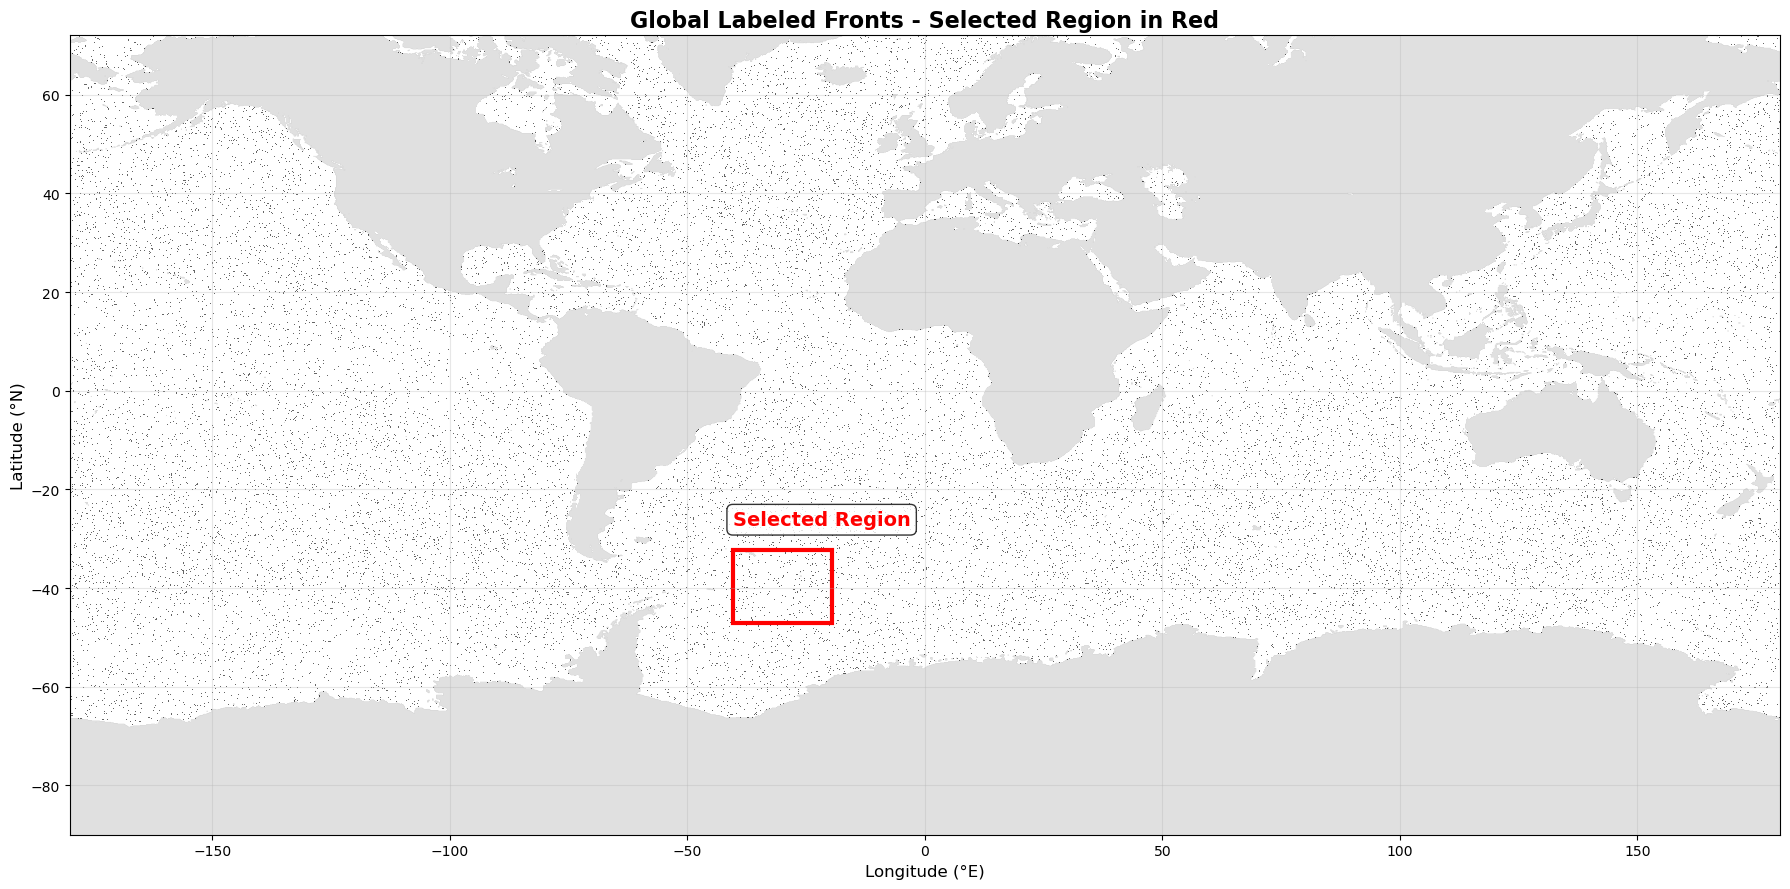

✓ Global context map


In [16]:
fig, ax = plt.subplots(figsize=(18, 9))

# Downsample for plotting
downsample = 10
labeled_display = labeled_global[::downsample, ::downsample]

# Create land mask
ocean_mask = divb2_global > 0
land_mask_display = ~ocean_mask[::downsample, ::downsample]

extent_global = [lon_global.min(), lon_global.max(),
                 lat_global.min(), lat_global.max()]

# Plot land (gray)
land_rgba = np.zeros((*land_mask_display.shape, 4))
land_rgba[land_mask_display] = [0.7, 0.7, 0.7, 1.0]
ax.imshow(land_rgba, extent=extent_global, origin='lower', aspect='auto')

# Plot fronts
ax.imshow(labeled_display > 0, extent=extent_global, origin='lower',
          aspect='auto', cmap='gray_r', alpha=0.6, interpolation='nearest')

# Red box for selected region
if not VISUALIZE_ENTIRE_GLOBE:
    rect = Rectangle(
        (region_bounds['lon_min'], region_bounds['lat_min']),
        region_bounds['lon_max'] - region_bounds['lon_min'],
        region_bounds['lat_max'] - region_bounds['lat_min'],
        fill=False, edgecolor='red', linewidth=3
    )
    ax.add_patch(rect)
    ax.text(region_bounds['lon_min'], region_bounds['lat_max'] + 5,
            'Selected Region', color='red', fontsize=14, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.set_xlabel('Longitude (°E)', fontsize=12)
ax.set_ylabel('Latitude (°N)', fontsize=12)
ax.set_title('Global Labeled Fronts - Selected Region in Red', fontsize=16, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"✓ Global context map")

## 4. Map: Before Labeling (Binary Fronts)

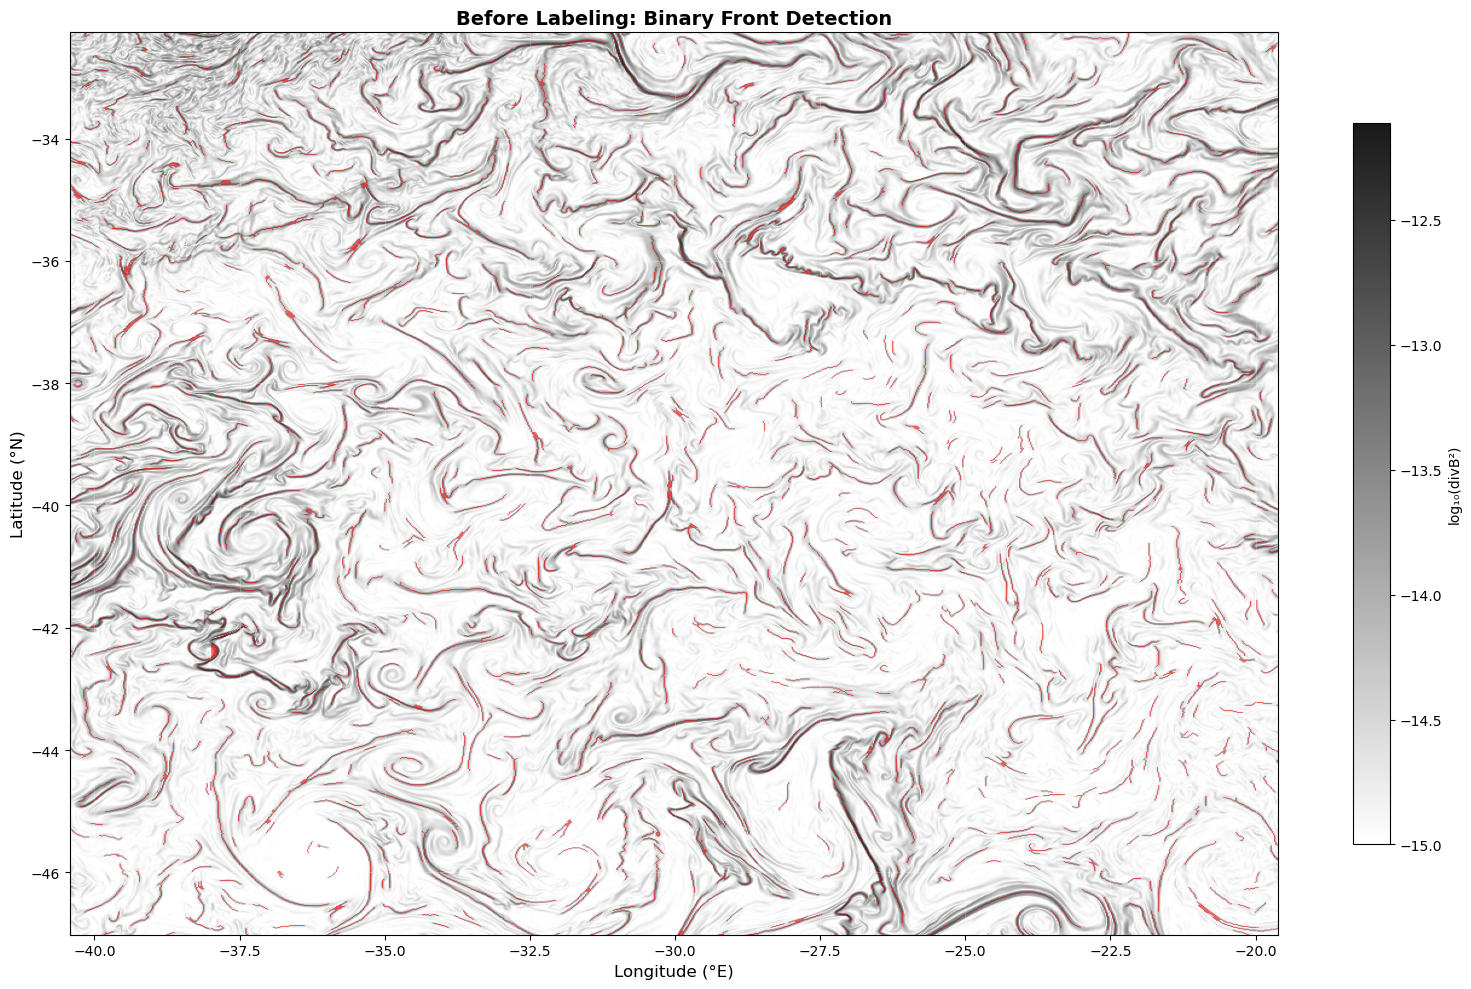

✓ Binary fronts map


In [17]:
fig, ax = plt.subplots(figsize=(16, 10))

extent_viz = [lon_viz.min(), lon_viz.max(), lat_viz.min(), lat_viz.max()]

# Plot log10(divB2) background
divb2_log = np.log10(divb2_viz + 1e-15)
im = ax.imshow(divb2_log, extent=extent_viz, origin='lower',
               aspect='auto', cmap='gray_r', alpha=0.9)
cbar = plt.colorbar(im, ax=ax, label='log₁₀(divB²)', shrink=0.8)

# Overlay binary fronts in red
fronts_rgba = np.zeros((*labeled_viz.shape, 4))
fronts_rgba[labeled_viz > 0] = [1, 0, 0, 0.6]
ax.imshow(fronts_rgba, extent=extent_viz, origin='lower', aspect='auto')

ax.set_xlabel('Longitude (°E)', fontsize=12)
ax.set_ylabel('Latitude (°N)', fontsize=12)
ax.set_title('Before Labeling: Binary Front Detection', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, color='white', linewidth=0.5)
plt.tight_layout()
plt.show()

print(f"✓ Binary fronts map")

## 5. Map: After Labeling (Color-Coded Groups)

Rendering 1,220 color-coded fronts...


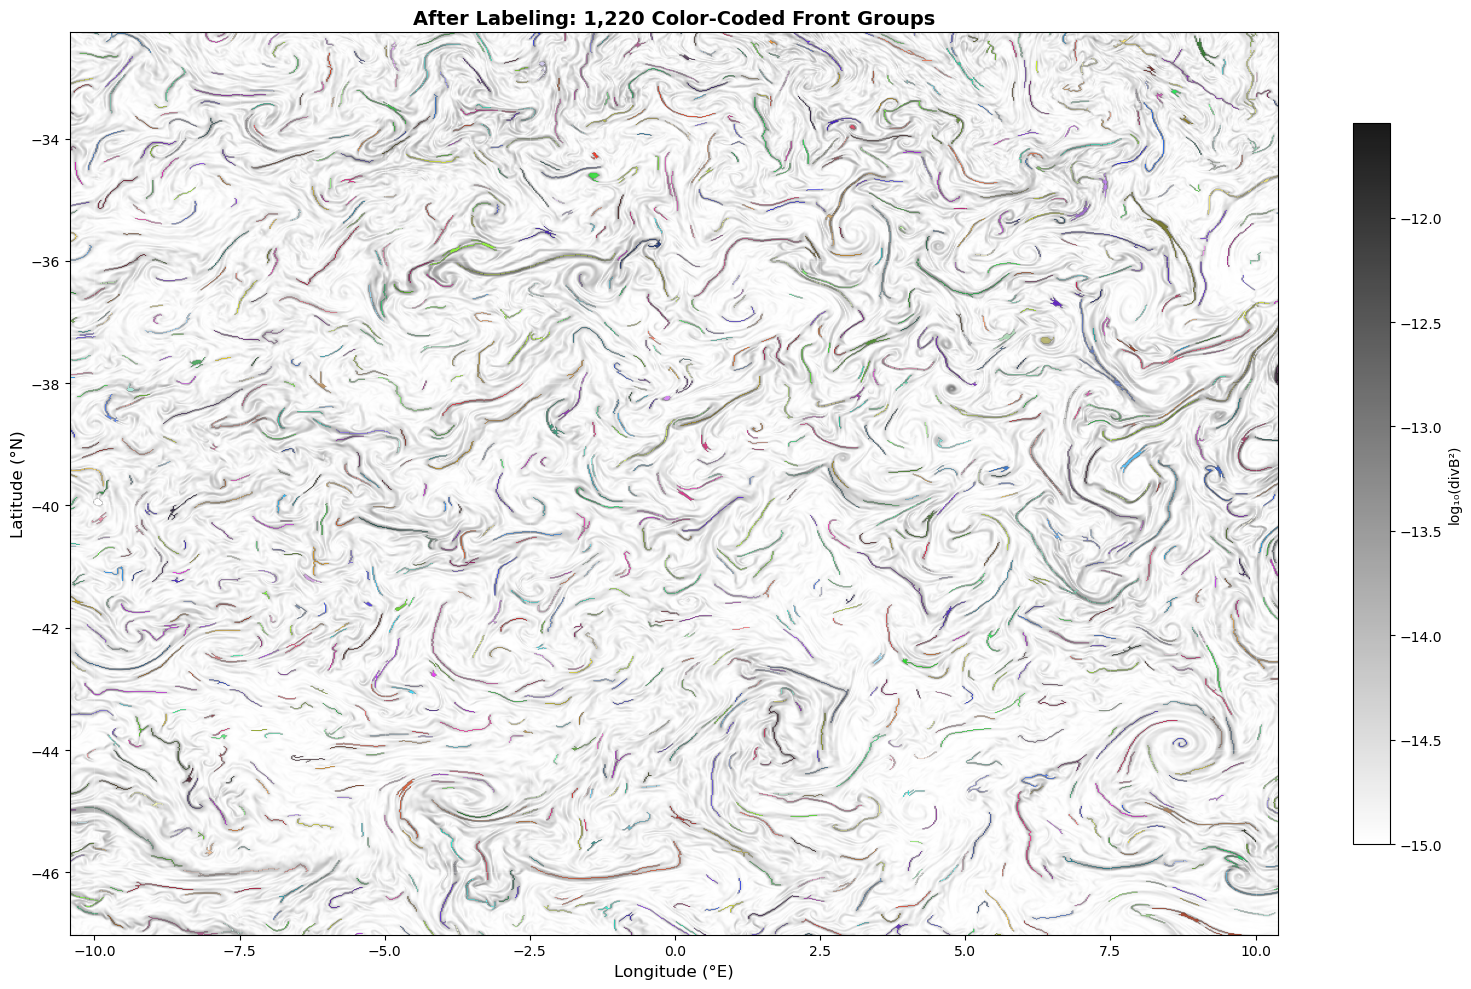

✓ Color-coded fronts map


In [14]:
fig, ax = plt.subplots(figsize=(16, 10))

extent_viz = [lon_viz.min(), lon_viz.max(), lat_viz.min(), lat_viz.max()]

# Plot log10(divB2) background
divb2_log = np.log10(divb2_viz + 1e-15)
im = ax.imshow(divb2_log, extent=extent_viz, origin='lower',
               aspect='auto', cmap='gray_r', alpha=0.9)
cbar = plt.colorbar(im, ax=ax, label='log₁₀(divB²)', shrink=0.8)

# Color-code fronts
unique_labels = np.unique(labeled_viz[labeled_viz > 0])
n_fronts = len(unique_labels)

print(f"Rendering {n_fronts:,} color-coded fronts...")

np.random.seed(42)
colors = np.random.rand(n_fronts, 3)

colored_fronts = np.zeros((*labeled_viz.shape, 3))
for idx, lbl in enumerate(unique_labels):
    mask = labeled_viz == lbl
    colored_fronts[mask] = colors[idx]

fronts_rgba = np.zeros((*labeled_viz.shape, 4))
fronts_rgba[..., :3] = colored_fronts
fronts_rgba[..., 3] = (labeled_viz > 0).astype(float) * 0.8

ax.imshow(fronts_rgba, extent=extent_viz, origin='lower', aspect='auto')

ax.set_xlabel('Longitude (°E)', fontsize=12)
ax.set_ylabel('Latitude (°N)', fontsize=12)
ax.set_title(f'After Labeling: {n_fronts:,} Color-Coded Front Groups', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, color='white', linewidth=0.5)
plt.tight_layout()
plt.show()

print(f"✓ Color-coded fronts map")

## 6. Filter Properties to Selected Region

In [4]:
# Filter dataframe to selected region
df_viz = df_global[
    (df_global['centroid_lat'] >= region_bounds['lat_min']) &
    (df_global['centroid_lat'] <= region_bounds['lat_max']) &
    (df_global['centroid_lon'] >= region_bounds['lon_min']) &
    (df_global['centroid_lon'] <= region_bounds['lon_max'])
]

print(f"Fronts in visualization region: {len(df_viz):,} / {len(df_global):,} total")
print(f"  ({100*len(df_viz)/len(df_global):.1f}% of global fronts)")

display(df_viz.head())

Fronts in visualization region: 135,252 / 135,252 total
  (100.0% of global fronts)


,label,front_id,time,npix,centroid_lat,centroid_lon,length_km,orientation,lat_min,lat_max,lon_min,lon_max,mean_curvature,curvature_direction
0,1,20121109T120000_78.5S_163.9W,2012-11-09T12:00:00,13,-78.456284,-163.876617,13.844637,26.285056,-78.466545,-78.444977,-163.990936,-163.763931,0.171292,0.171292
1,2,20121109T120000_78.3S_163.3W,2012-11-09T12:00:00,14,-78.290634,-163.338470,10.087704,34.869869,-78.328697,-78.255371,-163.437851,-163.235458,0.019787,-0.000069
2,3,20121109T120000_78.2S_164.5W,2012-11-09T12:00:00,65,-78.244919,-164.533646,66.343193,37.162251,-78.318199,-78.100769,-165.306046,-163.748947,0.055064,-0.005377
3,4,20121109T120000_78.2S_163.8W,2012-11-09T12:00:00,19,-78.234581,-163.767471,13.797300,45.223214,-78.275620,-78.173653,-163.892334,-163.677856,0.065180,0.055520
4,5,20121109T120000_78.2S_162.8W,2012-11-09T12:00:00,88,-78.152565,-162.849228,106.461205,20.659205,-78.224594,-78.072395,-163.048782,-162.523499,0.607676,-0.095567


## 7. Plot PDFs of Geometric Properties

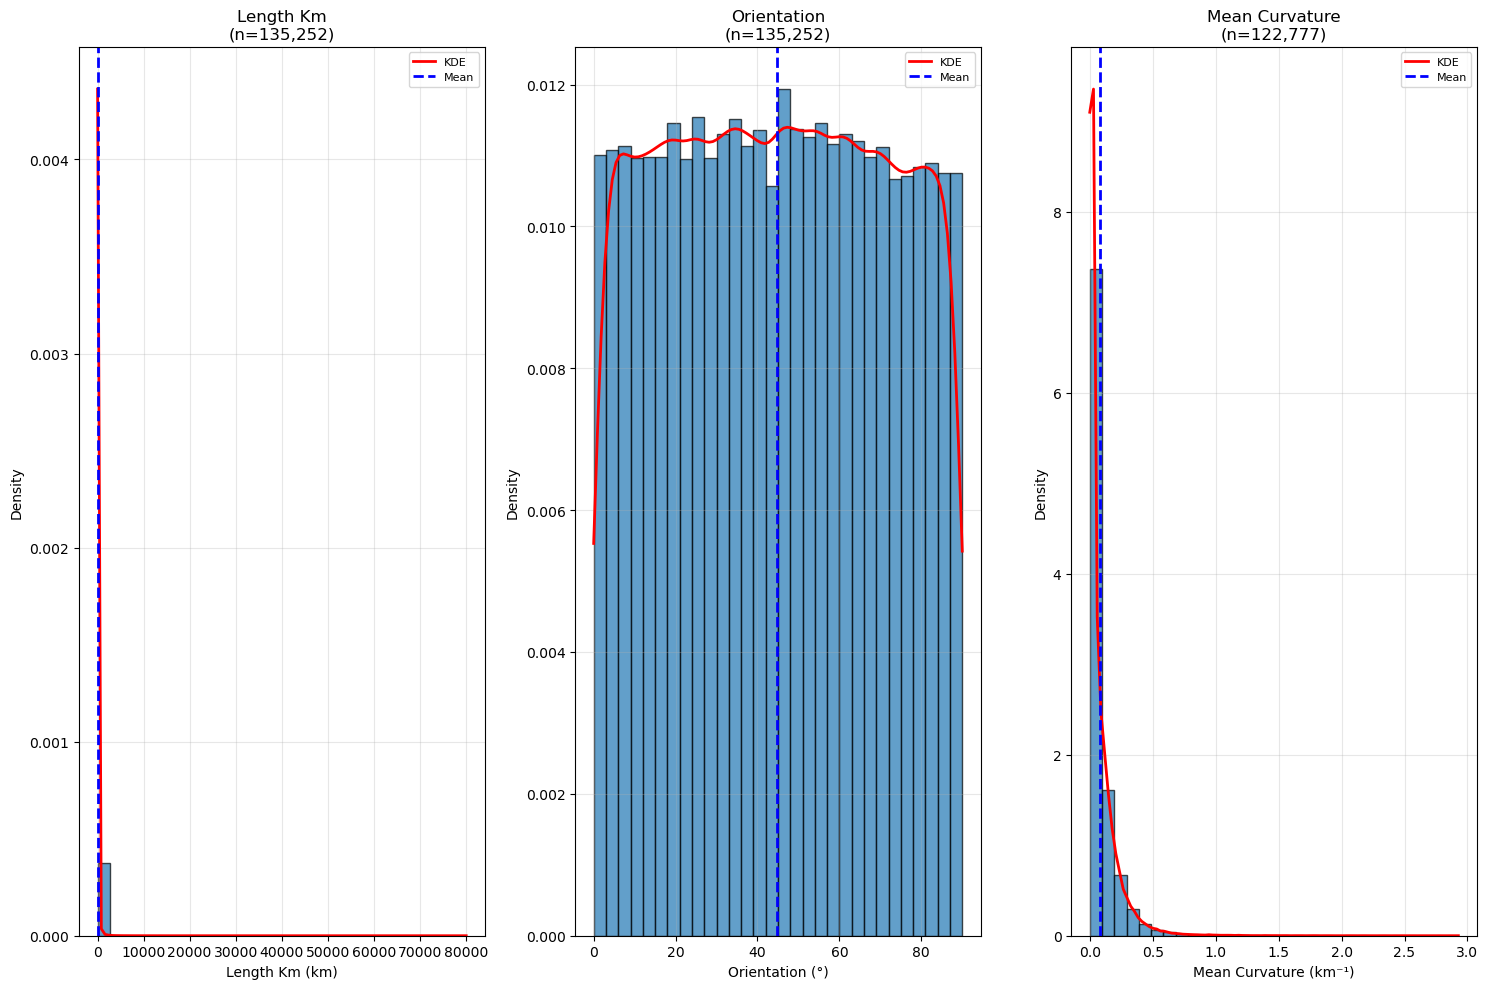

✓ PDFs plotted for 135,252 fronts


In [5]:
def plot_pdfs(df, properties, ncols=3, figsize=(15, 10)):
    """Plot PDFs for selected properties."""
    nrows = int(np.ceil(len(properties) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = axes.flatten() if nrows > 1 else [axes] if ncols == 1 else axes
    
    for idx, prop in enumerate(properties):
        ax = axes[idx]
        if prop not in df.columns:
            ax.text(0.5, 0.5, f'{prop}\nnot available', ha='center', va='center')
            ax.set_xticks([])
            ax.set_yticks([])
            continue
        
        if not pd.api.types.is_numeric_dtype(df[prop]):
            ax.text(0.5, 0.5, f'{prop}\n(non-numeric)', ha='center', va='center')
            ax.set_xticks([])
            ax.set_yticks([])
            continue
        
        data = df[prop].dropna()
        if len(data) == 0:
            ax.text(0.5, 0.5, f'{prop}\nno data', ha='center', va='center')
            ax.set_xticks([])
            ax.set_yticks([])
            continue
        
        ax.hist(data, bins=30, alpha=0.7, edgecolor='black', density=True)
        
        if len(data) > 10:
            try:
                kde = gaussian_kde(data)
                x_range = np.linspace(data.min(), data.max(), 100)
                ax.plot(x_range, kde(x_range), 'r-', linewidth=2, label='KDE')
            except:
                pass
        
        ax.axvline(data.mean(), color='blue', linestyle='--', linewidth=2, label='Mean')

        # Add units for specific properties
        units_map = {
            'length_km': ' (km)',
            'orientation': ' (°)',
            'mean_curvature': ' (km⁻¹)',
            'curvature_direction': ' (km⁻¹)',
            'lat_range': ' (°)',
            'lon_range': ' (°)'
        }
        units = units_map.get(prop, '')

        ax.set_xlabel(prop.replace('_', ' ').title() + units)
        ax.set_ylabel('Density')
        ax.set_title(f'{prop.replace("_", " ").title()}\n(n={len(data):,})')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    
    for idx in range(len(properties), len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    return fig

# Plot geometric properties
geom_to_plot = ['length_km', 'orientation', 'mean_curvature']
fig = plot_pdfs(df_viz, geom_to_plot)
plt.show()

print(f"✓ PDFs plotted for {len(df_viz):,} fronts")

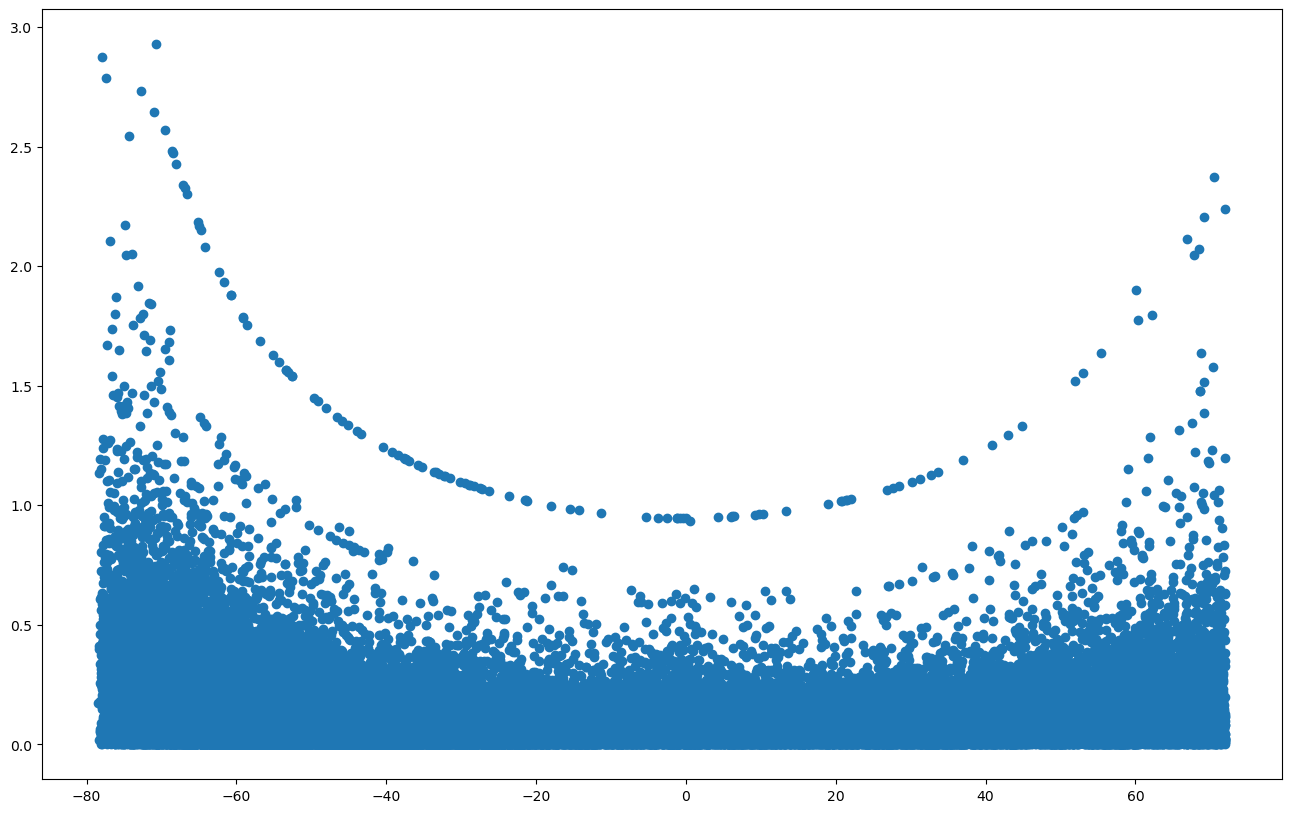

In [10]:


plt.scatter(df_viz['centroid_lat'],df_viz['mean_curvature'])

#plt.scatter(df_viz['centroid_lat'],df_viz['orientation'])

#plt.scatter(df_viz['centroid_lon'],df_viz['length_km'])

## 8. Summary Statistics

In [10]:
print("="*70)
print("SUMMARY STATISTICS")
print("="*70)
print(f"\nRegion: lat=[{region_bounds['lat_min']:.2f}, {region_bounds['lat_max']:.2f}], "
      f"lon=[{region_bounds['lon_min']:.2f}, {region_bounds['lon_max']:.2f}]")
print(f"\nFronts in region: {len(df_viz):,}")
print(f"Total global fronts: {len(df_global):,}")
print(f"Percentage: {100*len(df_viz)/len(df_global):.2f}%")

print(f"\nGeometric Properties:")
for prop in ['length_km', 'orientation', 'mean_curvature']:
    if prop in df_viz.columns:
        data = df_viz[prop].dropna()
        print(f"  {prop}:")
        print(f"    Mean: {data.mean():.2f}")
        print(f"    Median: {data.median():.2f}")
        print(f"    Std: {data.std():.2f}")
        print(f"    Range: [{data.min():.2f}, {data.max():.2f}]")

print("\n" + "="*70)

SUMMARY STATISTICS

Region: lat=[-9.61, 9.57], lon=[-175.43, -154.61]

Fronts in region: 745
Total global fronts: 135,252
Percentage: 0.55%

Geometric Properties:
  length_km:
    Mean: 191.54
    Median: 77.93
    Std: 367.94
    Range: [3.11, 4072.72]
  orientation:
    Mean: 35.72
    Median: 31.83
    Std: 23.32
    Range: [0.00, 90.00]
  mean_curvature:
    Mean: 0.06
    Median: 0.03
    Std: 0.09
    Range: [0.00, 0.96]

